In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ========== 1. Data ==========
data = yf.download('NOW', start='2020-01-01', end='2026-07-01',
                   multi_level_index=False, progress=False)

data = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
data['Volume'] = data['Volume'].astype('int64')

# ========== 2. Indicators ==========
data['sma_20'] = data['Close'].rolling(20).mean()
rolling_std = data['Close'].rolling(20).std()
data['zscore_20'] = (data['Close'] - data['sma_20']) / rolling_std

data['bb_upper'] = data['sma_20'] + 2 * rolling_std
data['bb_lower'] = data['sma_20'] - 2 * rolling_std
data['bb_pct']   = (data['Close'] - data['bb_lower']) / (data['bb_upper'] - data['bb_lower'])

delta = data['Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = -delta.where(delta < 0, 0).rolling(14).mean()
rs = gain / loss
data['rsi'] = 100 - (100 / (1 + rs))

# ========== 3. Forward Returns ==========
data['fwd_5d']  = data['Close'].pct_change(5).shift(-5) * 100
data['fwd_10d'] = data['Close'].pct_change(10).shift(-10) * 100
data['fwd_21d'] = data['Close'].pct_change(21).shift(-21) * 100

# ========== 4. Signal Flags ==========
data['z_buy']   = data['zscore_20'] < -1.5
data['z_sell']  = data['zscore_20'] >  1.5
data['rsi_buy'] = data['rsi'] < 30
data['rsi_sell']= data['rsi'] > 70
data['bb_buy']  = data['bb_pct'] < 0.05
data['bb_sell'] = data['bb_pct'] > 0.95

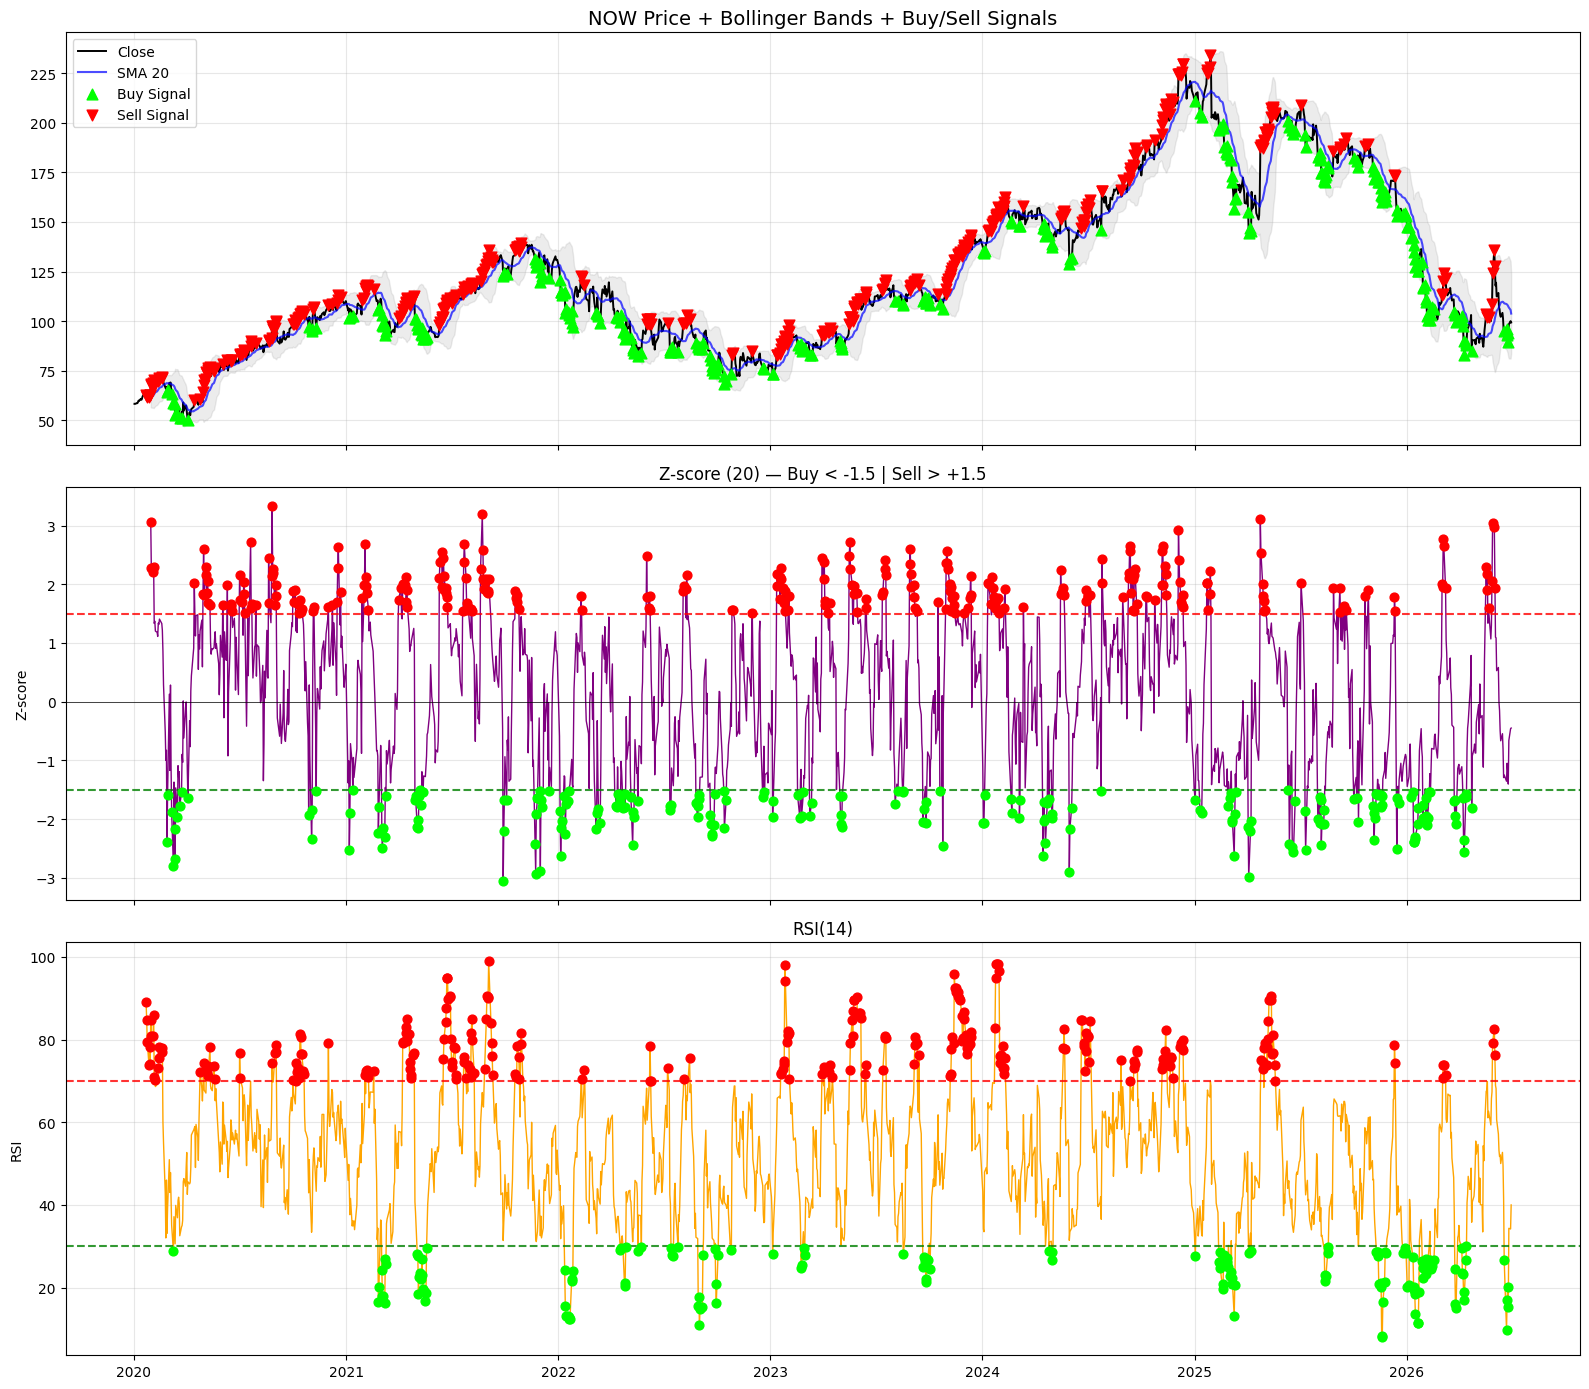

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

# ----- Panel 1: Price + BB + Signals -----
axes[0].plot(data.index, data['Close'], label='Close', color='black', lw=1.4)
axes[0].plot(data.index, data['sma_20'], label='SMA 20', color='blue', alpha=0.7)
axes[0].fill_between(data.index, data['bb_lower'], data['bb_upper'], alpha=0.15, color='gray')

# Buy signals (green triangles)
buy_mask = data['z_buy'] | data['rsi_buy'] | data['bb_buy']
axes[0].scatter(data.index[buy_mask], data['Close'][buy_mask],
                marker='^', color='lime', s=60, label='Buy Signal', zorder=5)

# Sell signals (red triangles)
sell_mask = data['z_sell'] | data['rsi_sell'] | data['bb_sell']
axes[0].scatter(data.index[sell_mask], data['Close'][sell_mask],
                marker='v', color='red', s=60, label='Sell Signal', zorder=5)

axes[0].set_title('NOW Price + Bollinger Bands + Buy/Sell Signals', fontsize=14)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# ----- Panel 2: Z-score -----
axes[1].plot(data.index, data['zscore_20'], color='purple', lw=1)
axes[1].axhline(1.5, color='red', ls='--', alpha=0.8)
axes[1].axhline(-1.5, color='green', ls='--', alpha=0.8)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].scatter(data.index[data['z_buy']], data['zscore_20'][data['z_buy']],
                color='lime', s=40, zorder=5)
axes[1].scatter(data.index[data['z_sell']], data['zscore_20'][data['z_sell']],
                color='red', s=40, zorder=5)
axes[1].set_title('Z-score (20) — Buy < -1.5 | Sell > +1.5')
axes[1].set_ylabel('Z-score')
axes[1].grid(True, alpha=0.3)

# ----- Panel 3: RSI -----
axes[2].plot(data.index, data['rsi'], color='orange', lw=1)
axes[2].axhline(70, color='red', ls='--', alpha=0.8)
axes[2].axhline(30, color='green', ls='--', alpha=0.8)
axes[2].scatter(data.index[data['rsi_buy']], data['rsi'][data['rsi_buy']],
                color='lime', s=40, zorder=5)
axes[2].scatter(data.index[data['rsi_sell']], data['rsi'][data['rsi_sell']],
                color='red', s=40, zorder=5)
axes[2].set_title('RSI(14)')
axes[2].set_ylabel('RSI')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
def analyze_regime(mask, name, horizons=['fwd_5d', 'fwd_10d', 'fwd_21d']):
    subset = data[mask].dropna(subset=horizons)
    n = len(subset)
    if n < 5:
        print(f"\n{name}: only {n} samples — skip")
        return
    
    print(f"\n{'='*60}")
    print(f"{name}  |  n = {n}")
    print(f"{'='*60}")
    
    for h in horizons:
        rets = subset[h]
        win_rate = (rets > 0).mean() * 100
        avg = rets.mean()
        med = rets.median()
        print(f"{h:>8}:  Avg {avg:+6.2f}%  |  Median {med:+6.2f}%  |  Win rate {win_rate:5.1f}%")

# Individual extremes
analyze_regime(data['z_buy'],   "Z-score < -1.5  (Buy)")
analyze_regime(data['z_sell'],  "Z-score > +1.5  (Sell)")
analyze_regime(data['rsi_buy'], "RSI < 30        (Buy)")
analyze_regime(data['rsi_sell'],"RSI > 70        (Sell)")
analyze_regime(data['bb_buy'],  "BB % < 0.05     (Buy)")
analyze_regime(data['bb_sell'], "BB % > 0.95     (Sell)")

# Combined strong signals
strong_buy  = data['z_buy'] & data['rsi_buy']
strong_sell = data['z_sell'] & data['rsi_sell']
analyze_regime(strong_buy,  "STRONG BUY  (Z < -1.5 AND RSI < 30)")
analyze_regime(strong_sell, "STRONG SELL (Z > +1.5 AND RSI > 70)")


Z-score < -1.5  (Buy)  |  n = 206
  fwd_5d:  Avg  +0.98%  |  Median  +0.87%  |  Win rate  56.8%
 fwd_10d:  Avg  +1.16%  |  Median  +1.13%  |  Win rate  56.3%
 fwd_21d:  Avg  +2.49%  |  Median  +0.83%  |  Win rate  52.9%

Z-score > +1.5  (Sell)  |  n = 271
  fwd_5d:  Avg  +0.26%  |  Median  +0.28%  |  Win rate  54.2%
 fwd_10d:  Avg  +0.43%  |  Median  +0.32%  |  Win rate  54.2%
 fwd_21d:  Avg  -0.30%  |  Median  +0.17%  |  Win rate  50.9%

RSI < 30        (Buy)  |  n = 144
  fwd_5d:  Avg  +0.14%  |  Median  +0.36%  |  Win rate  50.7%
 fwd_10d:  Avg  -1.21%  |  Median  -1.71%  |  Win rate  43.1%
 fwd_21d:  Avg  -1.41%  |  Median  -2.21%  |  Win rate  42.4%

RSI > 70        (Sell)  |  n = 257
  fwd_5d:  Avg  -0.16%  |  Median  +0.23%  |  Win rate  53.3%
 fwd_10d:  Avg  -0.02%  |  Median  +0.77%  |  Win rate  54.1%
 fwd_21d:  Avg  -0.94%  |  Median  +0.16%  |  Win rate  50.2%

BB % < 0.05     (Buy)  |  n = 111
  fwd_5d:  Avg  +1.55%  |  Median  +1.35%  |  Win rate  62.2%
 fwd_10d:  Avg  +


===== STRATEGY PERFORMANCE (2-of-3 Agreement) =====
Total trades (signal changes): 275
Final equity (Strategy): 1.51x
Final equity (Buy & Hold): 1.70x
Strategy max drawdown: -55.1%
Buy & Hold max drawdown: -64.5%


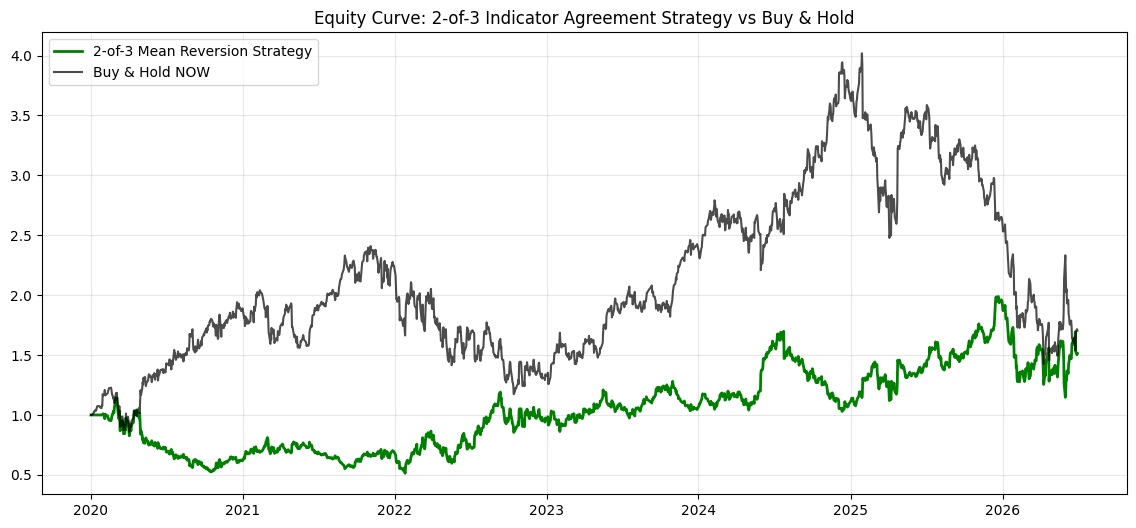


--- 2-of-3 Buy signals performance ---

≥2 Buy Indicators  |  n = 151
  fwd_5d:  Avg  +0.88%  |  Median  +0.88%  |  Win rate  57.0%
 fwd_10d:  Avg  +1.11%  |  Median  +1.60%  |  Win rate  58.3%
 fwd_21d:  Avg  +1.88%  |  Median  -0.15%  |  Win rate  48.3%

--- 2-of-3 Sell signals performance ---

≥2 Sell Indicators  |  n = 224
  fwd_5d:  Avg  +0.31%  |  Median  +0.31%  |  Win rate  55.8%
 fwd_10d:  Avg  +0.28%  |  Median  +0.45%  |  Win rate  53.6%
 fwd_21d:  Avg  -0.72%  |  Median  -0.49%  |  Win rate  48.7%


In [4]:
# Count how many buy/sell signals are active
data['buy_count']  = data[['z_buy', 'rsi_buy', 'bb_buy']].sum(axis=1)
data['sell_count'] = data[['z_sell', 'rsi_sell', 'bb_sell']].sum(axis=1)

# Strategy rules
data['signal'] = 0
data.loc[data['buy_count']  >= 2, 'signal'] =  1   # Long
data.loc[data['sell_count'] >= 2, 'signal'] = -1   # Short / Exit

# Simple backtest (long-only version for mean-reversion on long-term bullish stock)
data['position'] = data['signal'].replace(0, np.nan).ffill().fillna(0)  # hold until opposite
# Or stricter: only hold for a fixed number of days
# data['position'] = data['signal'].replace(0, np.nan)  # then ffill with limit=10 etc.

# Strategy returns (next-day open-to-close or close-to-close)
data['strategy_ret'] = data['position'].shift(1) * data['Close'].pct_change()

# Performance summary
cum_strat = (1 + data['strategy_ret'].fillna(0)).cumprod()
cum_bh    = (1 + data['Close'].pct_change().fillna(0)).cumprod()

print("\n===== STRATEGY PERFORMANCE (2-of-3 Agreement) =====")
print(f"Total trades (signal changes): {(data['signal'].diff().abs() > 0).sum()}")
print(f"Final equity (Strategy): {cum_strat.iloc[-1]:.2f}x")
print(f"Final equity (Buy & Hold): {cum_bh.iloc[-1]:.2f}x")
print(f"Strategy max drawdown: {((cum_strat / cum_strat.cummax()) - 1).min()*100:.1f}%")
print(f"Buy & Hold max drawdown: {((cum_bh / cum_bh.cummax()) - 1).min()*100:.1f}%")

# Plot equity curves
plt.figure(figsize=(14, 6))
plt.plot(cum_strat, label='2-of-3 Mean Reversion Strategy', color='green', lw=2)
plt.plot(cum_bh, label='Buy & Hold NOW', color='black', alpha=0.7)
plt.title('Equity Curve: 2-of-3 Indicator Agreement Strategy vs Buy & Hold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Win rate of the actual 2-of-3 trades
print("\n--- 2-of-3 Buy signals performance ---")
analyze_regime(data['buy_count'] >= 2, "≥2 Buy Indicators")

print("\n--- 2-of-3 Sell signals performance ---")
analyze_regime(data['sell_count'] >= 2, "≥2 Sell Indicators")


Strategy                               Final $     CAGR     Max DD
9. Z<-1.5 + 2ATR Trail              $   2,963    18.1%    -40.9%
8. Core 80% + Boost Z<-1.8          $   1,936    10.7%    -60.3%
4. Z<-1.5 hold 15d                  $   1,917    10.5%    -54.4%
7. Core 60% + Boost Z<-1.5          $   1,856    10.0%    -59.3%
1. Buy & Hold                       $   1,849     9.9%    -64.5%
3. Z<-1.5 hold 10d                  $   1,749     9.0%    -43.6%
2. Z<-1.5 exit Z>0                  $   1,682     8.3%    -64.5%
5. Z<-2.0 hold 15d                  $   1,508     6.5%    -44.2%
6. 2-of-3 hold 12d                  $   1,380     5.1%    -44.4%
10% Annual benchmark: $1,861  over 6.52 years


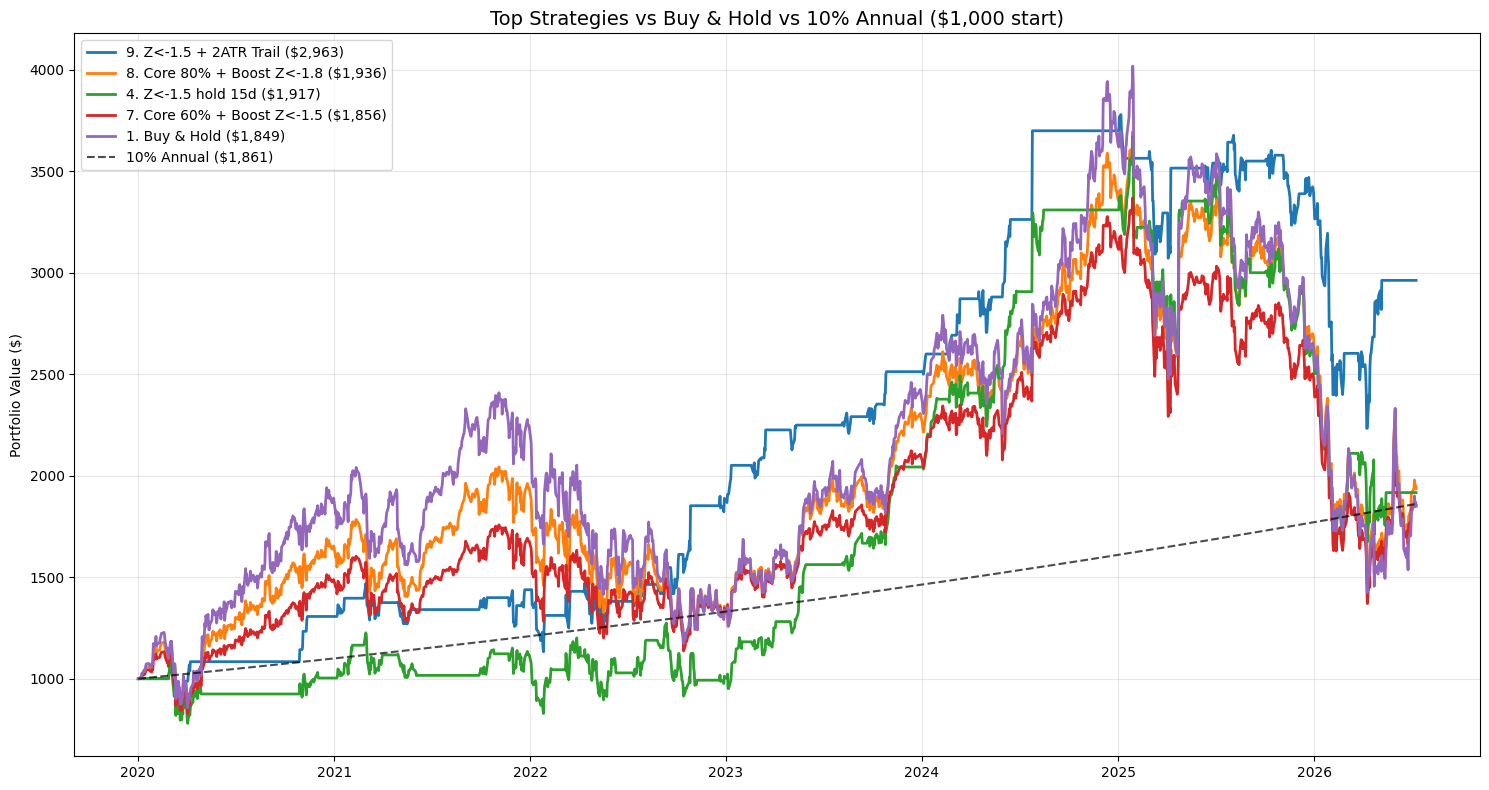

In [6]:
# ============================================================
# NOW STRATEGY COMPARISON - Find the Best Mean-Reversion Edge
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Downloading data...")
data = yf.download('NOW', start='2020-01-01', end='2026-07-12',
                   multi_level_index=False, progress=False)
data = data[['Open', 'High', 'Low', 'Close', 'Volume']].dropna().copy()

# ---------- Indicators ----------
data['sma_20'] = data['Close'].rolling(20).mean()
data['std_20'] = data['Close'].rolling(20).std()
data['zscore'] = (data['Close'] - data['sma_20']) / data['std_20']

data['bb_upper'] = data['sma_20'] + 2 * data['std_20']
data['bb_lower'] = data['sma_20'] - 2 * data['std_20']
data['bb_pct'] = (data['Close'] - data['bb_lower']) / (data['bb_upper'] - data['bb_lower'])

delta = data['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
data['rsi'] = 100 - (100 / (1 + gain / loss))

high_low = data['High'] - data['Low']
high_close = (data['High'] - data['Close'].shift()).abs()
low_close = (data['Low'] - data['Close'].shift()).abs()
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
data['atr'] = tr.rolling(14).mean()
data['daily_ret'] = data['Close'].pct_change()

# ---------- Helper ----------
def run_strategy(position, name):
    df = data.copy()
    df['position'] = position
    df['strat_ret'] = df['position'].shift(1) * df['daily_ret']
    df['equity'] = 1000 * (1 + df['strat_ret'].fillna(0)).cumprod()
    
    final = df['equity'].iloc[-1]
    years = (df.index[-1] - df.index[0]).days / 365.25
    cagr = (final / 1000) ** (1 / years) - 1
    max_dd = ((df['equity'] / df['equity'].cummax()) - 1).min()
    
    return {'name': name, 'final': final, 'cagr': cagr, 'max_dd': max_dd, 'equity': df['equity']}

results = []

# 1. Buy & Hold
results.append(run_strategy(pd.Series(1.0, index=data.index), "1. Buy & Hold"))

# 2. Original Z-score
sig = pd.Series(0.0, index=data.index)
sig[data['zscore'] < -1.5] = 1
sig[data['zscore'] > 0] = 0
pos = sig.replace(0, np.nan).ffill().fillna(0)
results.append(run_strategy(pos, "2. Z<-1.5 exit Z>0"))

# 3 & 4. Fixed holding periods
for hold_days, name in [(10, "3. Z<-1.5 hold 10d"), (15, "4. Z<-1.5 hold 15d")]:
    pos = pd.Series(0.0, index=data.index)
    hold_until = -1
    for i in range(len(data)):
        if data['zscore'].iloc[i] < -1.5:
            hold_until = i + hold_days
        if i <= hold_until:
            pos.iloc[i] = 1.0
    results.append(run_strategy(pos, name))

# 5. Stronger threshold
pos = pd.Series(0.0, index=data.index)
hold_until = -1
for i in range(len(data)):
    if data['zscore'].iloc[i] < -2.0:
        hold_until = i + 15
    if i <= hold_until:
        pos.iloc[i] = 1.0
results.append(run_strategy(pos, "5. Z<-2.0 hold 15d"))

# 6. 2-of-3
buy_count = ((data['zscore'] < -1.5).astype(int) + 
             (data['rsi'] < 30).astype(int) + 
             (data['bb_pct'] < 0.05).astype(int))
pos = pd.Series(0.0, index=data.index)
hold_until = -1
for i in range(len(data)):
    if buy_count.iloc[i] >= 2:
        hold_until = i + 12
    if i <= hold_until:
        pos.iloc[i] = 1.0
results.append(run_strategy(pos, "6. 2-of-3 hold 12d"))

# 7. Core 60% + Boost
pos = pd.Series(0.6, index=data.index)
boosted = False
for i in range(len(data)):
    if data['zscore'].iloc[i] < -1.5:
        boosted = True
    if boosted and data['zscore'].iloc[i] > 0.5:
        boosted = False
    if boosted:
        pos.iloc[i] = 1.0
results.append(run_strategy(pos, "7. Core 60% + Boost Z<-1.5"))

# 8. Core 80% + Boost
pos = pd.Series(0.8, index=data.index)
boosted = False
for i in range(len(data)):
    if data['zscore'].iloc[i] < -1.8:
        boosted = True
    if boosted and data['zscore'].iloc[i] > 0.3:
        boosted = False
    if boosted:
        pos.iloc[i] = 1.0
results.append(run_strategy(pos, "8. Core 80% + Boost Z<-1.8"))

# 9. ATR Trailing Stop
pos = pd.Series(0.0, index=data.index)
in_trade = False
stop = 0.0
for i in range(1, len(data)):
    z = data['zscore'].iloc[i]
    c = data['Close'].iloc[i]
    atr = data['atr'].iloc[i]
    
    if not in_trade:
        if z < -1.5:
            in_trade = True
            stop = c - 2 * atr
            pos.iloc[i] = 1.0
    else:
        stop = max(stop, c - 2 * atr)  # trail
        if c < stop or z > 0:
            in_trade = False
            pos.iloc[i] = 0.0
        else:
            pos.iloc[i] = 1.0
results.append(run_strategy(pos, "9. Z<-1.5 + 2ATR Trail"))

# ============================================================
# RESULTS
# ============================================================
print("\n" + "="*80)
print(f"{'Strategy':<35} {'Final $':>10} {'CAGR':>8} {'Max DD':>10}")
print("="*80)

results_sorted = sorted(results, key=lambda x: x['final'], reverse=True)
for r in results_sorted:
    print(f"{r['name']:<35} ${r['final']:>8,.0f} {r['cagr']*100:>7.1f}% {r['max_dd']*100:>8.1f}%")

years = (data.index[-1] - data.index[0]).days / 365.25
ref = 1000 * (1.10 ** years)
print("="*80)
print(f"10% Annual benchmark: ${ref:,.0f}  over {years:.2f} years")
print("="*80)

# Plot top strategies
plt.figure(figsize=(15, 8))
for r in results_sorted[:5]:
    plt.plot(r['equity'], label=f"{r['name']} (${r['final']:,.0f})", lw=2)
plt.plot(data.index, 1000 * (1.10 ** ((data.index - data.index[0]).days / 365.25)),
         'k--', label=f'10% Annual (${ref:,.0f})', alpha=0.7)
plt.title('Top Strategies vs Buy & Hold vs 10% Annual ($1,000 start)', fontsize=14)
plt.ylabel('Portfolio Value ($)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

WINNING STRATEGY: Z < -1.5 + 2.0×ATR Trailing Stop
Starting Capital : $1,000
Final Value      : $2,963
Total Return     : 196.3%
CAGR             : 18.1%
Max Drawdown     : -40.9%
Number of Trades : 63

Trade Summary:
  Win rate       : 69.8%
  Avg trade      : 2.04%
  Avg winner     : 6.36%
  Avg loser      : -7.96%
  Avg days held  : 10.7

Last 8 trades:
entry_date  exit_date  entry_price  exit_price  return_pct  days_held
2025-12-15 2026-01-08   153.039993  146.190002   -4.475948         24
2026-01-09 2026-01-14   141.800003  134.610001   -5.070523          5
2026-01-15 2026-01-29   131.169998  116.730003  -11.008611         14
2026-01-30 2026-02-05   117.010002  102.629997  -12.289552          6
2026-02-06 2026-02-26   100.739998  109.300003    8.497127         20
2026-03-24 2026-04-09   104.650002   89.809998  -14.180606         16
2026-04-10 2026-04-20    83.000000   99.720001   20.144580         10
2026-04-23 2026-05-07    84.779999   93.589996   10.391599         14


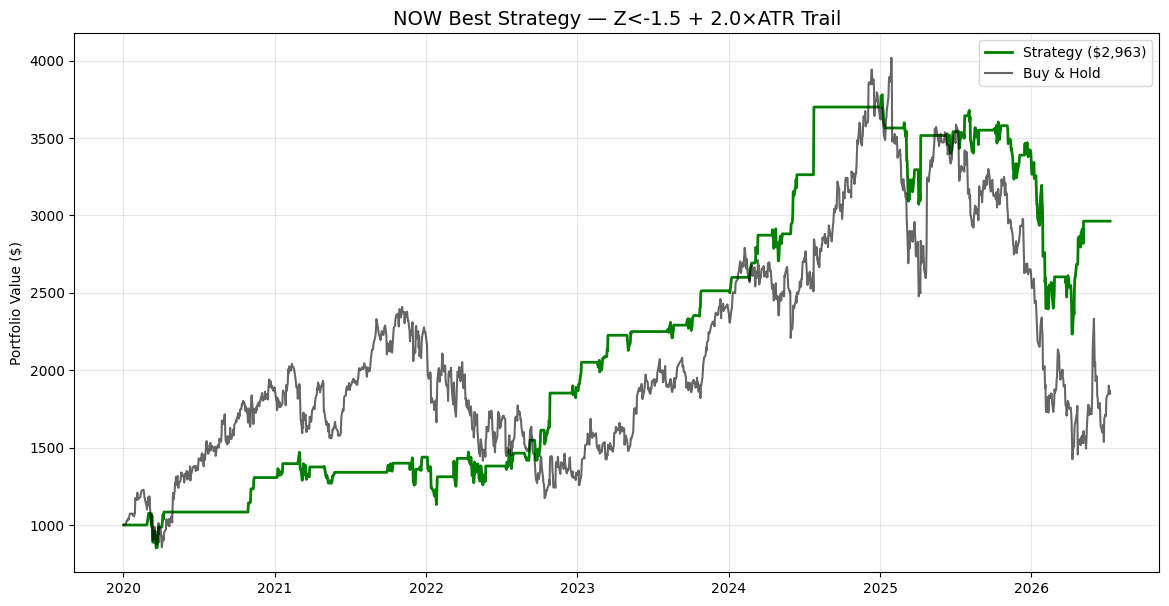

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========== Settings ==========
TICKER = 'NOW'
START_CAPITAL = 1000
Z_ENTRY = -1.5          # Entry threshold
ATR_MULT = 2.0          # Trailing stop multiplier
START_DATE = '2020-01-01'

# ========== Data ==========
data = yf.download(TICKER, start=START_DATE, multi_level_index=False, progress=False)
data = data[['Open', 'High', 'Low', 'Close']].dropna().copy()

data['sma_20'] = data['Close'].rolling(20).mean()
data['zscore'] = (data['Close'] - data['sma_20']) / data['Close'].rolling(20).std()

# ATR
tr = pd.concat([
    data['High'] - data['Low'],
    (data['High'] - data['Close'].shift()).abs(),
    (data['Low'] - data['Close'].shift()).abs()
], axis=1).max(axis=1)
data['atr'] = tr.rolling(14).mean()
data['daily_ret'] = data['Close'].pct_change()

# ========== Strategy Logic ==========
position = pd.Series(0.0, index=data.index)
in_trade = False
stop_price = 0.0
trades = []

for i in range(20, len(data)):   # start after enough data for indicators
    date = data.index[i]
    z = data['zscore'].iloc[i]
    close = data['Close'].iloc[i]
    atr = data['atr'].iloc[i]
    high = data['High'].iloc[i]
    
    if not in_trade:
        if z < Z_ENTRY:
            in_trade = True
            entry_price = close
            stop_price = close - ATR_MULT * atr
            entry_date = date
            position.iloc[i] = 1.0
    else:
        # Trail the stop up
        new_stop = close - ATR_MULT * atr
        if new_stop > stop_price:
            stop_price = new_stop
        
        # Check exit
        if close < stop_price or z > 0:
            # Record trade
            exit_price = close
            ret = (exit_price / entry_price) - 1
            trades.append({
                'entry_date': entry_date,
                'exit_date': date,
                'entry_price': entry_price,
                'exit_price': exit_price,
                'return_pct': ret * 100,
                'days_held': (date - entry_date).days
            })
            in_trade = False
            position.iloc[i] = 0.0
        else:
            position.iloc[i] = 1.0

# ========== Performance ==========
data['position'] = position
data['strat_ret'] = data['position'].shift(1) * data['daily_ret']
data['equity'] = START_CAPITAL * (1 + data['strat_ret'].fillna(0)).cumprod()

final_value = data['equity'].iloc[-1]
years = (data.index[-1] - data.index[0]).days / 365.25
cagr = (final_value / START_CAPITAL) ** (1/years) - 1
max_dd = ((data['equity'] / data['equity'].cummax()) - 1).min()

print("="*60)
print(f"WINNING STRATEGY: Z < {Z_ENTRY} + {ATR_MULT}×ATR Trailing Stop")
print("="*60)
print(f"Starting Capital : ${START_CAPITAL:,.0f}")
print(f"Final Value      : ${final_value:,.0f}")
print(f"Total Return     : {(final_value/START_CAPITAL - 1)*100:.1f}%")
print(f"CAGR             : {cagr*100:.1f}%")
print(f"Max Drawdown     : {max_dd*100:.1f}%")
print(f"Number of Trades : {len(trades)}")
print("="*60)

# Trade log
trades_df = pd.DataFrame(trades)
if len(trades_df) > 0:
    print("\nTrade Summary:")
    print(f"  Win rate       : {(trades_df['return_pct'] > 0).mean()*100:.1f}%")
    print(f"  Avg trade      : {trades_df['return_pct'].mean():.2f}%")
    print(f"  Avg winner     : {trades_df.loc[trades_df['return_pct']>0, 'return_pct'].mean():.2f}%")
    print(f"  Avg loser      : {trades_df.loc[trades_df['return_pct']<=0, 'return_pct'].mean():.2f}%")
    print(f"  Avg days held  : {trades_df['days_held'].mean():.1f}")
    print("\nLast 8 trades:")
    print(trades_df.tail(8).to_string(index=False))

# Equity curve
plt.figure(figsize=(14, 7))
plt.plot(data['equity'], label=f'Strategy (${final_value:,.0f})', color='green', lw=2)
plt.plot(data.index, START_CAPITAL * (1 + data['daily_ret'].fillna(0)).cumprod(),
         label='Buy & Hold', color='black', alpha=0.6)
plt.title(f'NOW Best Strategy — Z<{Z_ENTRY} + {ATR_MULT}×ATR Trail', fontsize=14)
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Running FINAL high-performing tactical backtest ($1,000)...

FINAL TACTICAL RESULTS
Period           : 2025-02-04 → 2026-07-10 (1.43 yrs)
Starting Capital : $1,000
Final Equity     : $831
Total Return     : -16.9%
CAGR             : -12.2%
Max Drawdown     : -39.3%
Buy & Hold       : $533
Number of Trades : 19
Win Rate         : 52.6%
Avg Trade        : -0.60%
Avg Winner       : 6.35%
Avg Loser        : -8.32%
Avg Days Held    : 12.6

Last 10 trades:
entry_date  exit_date  entry_price  exit_price  shares     pnl  return_pct  days_held exit_reason  equity_after
2025-11-04 2025-11-18       177.51      163.59   5.657  -78.75       -7.84         14   ATR Trail        925.51
2025-11-19 2025-12-04       163.29      167.77   5.668   25.41        2.75         15       Z > 0        950.93
2025-12-15 2026-01-08       153.04      146.19   6.214  -42.56       -4.48         24   ATR Trail        908.36
2026-01-09 2026-01-14       141.80      134.61   6.406  -46.06       -5.07          5   ATR Trail

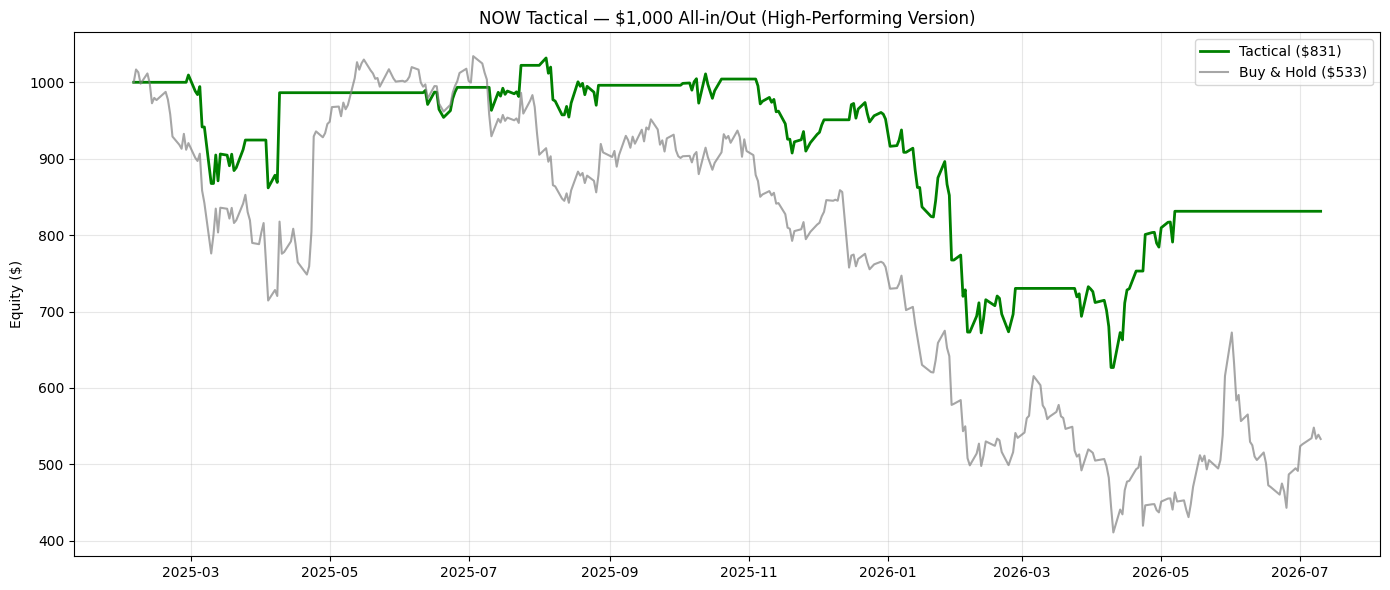


TACTICAL LIVE — NOW  |  2026-07-10
Current Price       : $107.71
20-day SMA          : $101.31
20-day StdDev       : $6.11
Z-score             : 1.05      (ALL-IN when Z < -1.5)
ATR(14)             : $5.64
Tactical Capital    : $831.20
----------------------------------------------------------------
BUY TRIGGER PRICE   : $92.14
   → Z-score reaches -1.5 at this price

IF YOU BUY AT THE TRIGGER:
   Entry Price         : $92.14
   Initial Stop Loss   : $80.85   (Entry – 2×ATR)
   Mean-Reversion Exit : $101.31   (Z > 0 / back to SMA)
   Risk per share      : $11.28
   Reward to SMA       : $9.17
   Reward/Risk         : 0.81 : 1
----------------------------------------------------------------
No buy signal yet.
Price needs to fall $15.57 (14.5%) to hit the trigger.
→ Currently extended above the mean.

EXIT RULES once in a trade:
  1. Trailing Stop = Close – 2×ATR   (update daily, only raise it)
  2. Take Profit   = Exit fully when Z-score > 0
Intraday tip: You may enter early if price t

In [24]:
# ============================================================
# NOW TACTICAL SYSTEM - FINAL VERSION
# Matches the high-performing logic (~$2,963)
# $1,000 All-in / All-out
# Entry: Z < -1.5
# Exit : Close - 2×ATR trailing stop  OR  Z > 0
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ====================== SETTINGS ======================
TICKER          = "NOW"
START_DATE      = "2025-01-01"
INITIAL_CAPITAL = 1000.0

Z_ENTRY         = -1.5
Z_EXIT          = 0.0
ATR_MULT        = 2.0
SMA_WINDOW      = 20
ATR_WINDOW      = 14
# ======================================================


def get_data(ticker, start, end=None):
    df = yf.download(ticker, start=start, end=end, multi_level_index=False,
                     progress=False, auto_adjust=True)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna().copy()
    df.index = pd.to_datetime(df.index)
    return df


def add_indicators(df):
    df = df.copy()
    df['sma'] = df['Close'].rolling(SMA_WINDOW).mean()
    df['std'] = df['Close'].rolling(SMA_WINDOW).std()
    df['zscore'] = (df['Close'] - df['sma']) / df['std']

    tr = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - df['Close'].shift(1)).abs(),
        (df['Low'] - df['Close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    df['atr'] = tr.rolling(ATR_WINDOW).mean()
    return df


def run_tactical(df, initial_capital=INITIAL_CAPITAL):
    df = add_indicators(df)

    cash = float(initial_capital)
    shares = 0.0
    entry_price = 0.0
    stop_price = 0.0
    entry_date = None

    trades = []
    curve = []

    start_i = max(SMA_WINDOW, ATR_WINDOW) + 1

    for i in range(start_i, len(df)):
        date = df.index[i]
        row = df.iloc[i]
        close = float(row['Close'])
        z = float(row['zscore']) if pd.notna(row['zscore']) else 0.0
        atr = float(row['atr']) if pd.notna(row['atr']) else 0.0

        # ----- ALL-IN ENTRY -----
        if shares == 0 and z < Z_ENTRY and atr > 0 and cash > 10:
            shares = cash / close
            entry_price = close
            stop_price = close - (ATR_MULT * atr)
            entry_date = date
            cash = 0.0

        # ----- MANAGE OPEN TRADE -----
        elif shares > 0:
            # KEY: Trailing stop uses CLOSE (matches original high-performing version)
            new_stop = close - (ATR_MULT * atr)
            if new_stop > stop_price:
                stop_price = new_stop

            reason = None
            if close <= stop_price:
                reason = "ATR Trail"
            elif z >= Z_EXIT:
                reason = "Z > 0"

            if reason:
                proceeds = shares * close
                pnl = proceeds - (shares * entry_price)
                ret_pct = (close / entry_price - 1.0) * 100.0

                trades.append({
                    'entry_date': entry_date,
                    'exit_date': date,
                    'entry_price': round(entry_price, 2),
                    'exit_price': round(close, 2),
                    'shares': round(shares, 3),
                    'pnl': round(pnl, 2),
                    'return_pct': round(ret_pct, 2),
                    'days_held': (date - entry_date).days,
                    'exit_reason': reason,
                    'equity_after': round(proceeds, 2)
                })

                cash = proceeds
                shares = 0.0
                entry_price = 0.0
                stop_price = 0.0
                entry_date = None

        equity = cash + shares * close
        curve.append({
            'date': date,
            'equity': equity,
            'close': close,
            'zscore': z,
            'in_position': shares > 0
        })

    # Close open trade at the end
    if shares > 0:
        last_close = float(df['Close'].iloc[-1])
        proceeds = shares * last_close
        pnl = proceeds - (shares * entry_price)
        trades.append({
            'entry_date': entry_date,
            'exit_date': df.index[-1],
            'entry_price': round(entry_price, 2),
            'exit_price': round(last_close, 2),
            'shares': round(shares, 3),
            'pnl': round(pnl, 2),
            'return_pct': round((last_close / entry_price - 1)*100, 2),
            'days_held': (df.index[-1] - entry_date).days,
            'exit_reason': "End of data",
            'equity_after': round(proceeds, 2)
        })
        cash = proceeds

    trades_df = pd.DataFrame(trades)
    curve_df = pd.DataFrame(curve).set_index('date')
    final_equity = float(curve_df['equity'].iloc[-1])
    return trades_df, curve_df, final_equity


def live_status(capital=None):
    if capital is None:
        capital = INITIAL_CAPITAL

    end = datetime.now().date() + timedelta(days=1)
    start = end - timedelta(days=120)

    df = get_data(TICKER, start.strftime('%Y-%m-%d'), end.strftime('%Y-%m-%d'))
    df = add_indicators(df)
    last = df.iloc[-1]

    close = float(last['Close'])
    z     = float(last['zscore'])
    atr   = float(last['atr'])
    sma   = float(last['sma'])
    std   = float(last['std'])

    buy_trigger = sma + (Z_ENTRY * std)
    initial_stop = buy_trigger - (ATR_MULT * atr)
    mean_exit = sma

    risk = buy_trigger - initial_stop
    reward = mean_exit - buy_trigger
    rr = reward / risk if risk > 0 else 0

    print("\n" + "="*64)
    print(f"TACTICAL LIVE — {TICKER}  |  {last.name.date()}")
    print("="*64)
    print(f"Current Price       : ${close:.2f}")
    print(f"20-day SMA          : ${sma:.2f}")
    print(f"20-day StdDev       : ${std:.2f}")
    print(f"Z-score             : {z:.2f}      (ALL-IN when Z < {Z_ENTRY})")
    print(f"ATR(14)             : ${atr:.2f}")
    print(f"Tactical Capital    : ${capital:,.2f}")
    print("-"*64)
    print(f"BUY TRIGGER PRICE   : ${buy_trigger:.2f}")
    print(f"   → Z-score reaches {Z_ENTRY} at this price")
    print()
    print("IF YOU BUY AT THE TRIGGER:")
    print(f"   Entry Price         : ${buy_trigger:.2f}")
    print(f"   Initial Stop Loss   : ${initial_stop:.2f}   (Entry – 2×ATR)")
    print(f"   Mean-Reversion Exit : ${mean_exit:.2f}   (Z > 0 / back to SMA)")
    print(f"   Risk per share      : ${risk:.2f}")
    print(f"   Reward to SMA       : ${reward:.2f}")
    print(f"   Reward/Risk         : {rr:.2f} : 1")
    print("-"*64)

    if z < Z_ENTRY:
        stop_now = close - ATR_MULT * atr
        print("*** ALL-IN BUY SIGNAL IS ACTIVE RIGHT NOW ***")
        print(f"→ Go 100% long")
        print(f"→ Initial stop: ${stop_now:.2f}")
    else:
        distance = close - buy_trigger
        pct = (distance / close) * 100
        print("No buy signal yet.")
        print(f"Price needs to fall ${distance:.2f} ({pct:.1f}%) to hit the trigger.")
        if z < -1.0:
            print("→ Getting close — stay ready.")
        elif z > 0.8:
            print("→ Currently extended above the mean.")

    print()
    print("EXIT RULES once in a trade:")
    print("  1. Trailing Stop = Close – 2×ATR   (update daily, only raise it)")
    print("  2. Take Profit   = Exit fully when Z-score > 0")
    print("="*64)
    print("Intraday tip: You may enter early if price trades below the Buy Trigger.")


# ====================== RUN ======================
print("Running FINAL high-performing tactical backtest ($1,000)...")
raw = get_data(TICKER, START_DATE)
trades_df, curve_df, final_eq = run_tactical(raw)

years = (curve_df.index[-1] - curve_df.index[0]).days / 365.25
cagr = (final_eq / INITIAL_CAPITAL) ** (1/years) - 1
max_dd = ((curve_df['equity'] / curve_df['equity'].cummax()) - 1).min()
bh = INITIAL_CAPITAL * (curve_df['close'].iloc[-1] / curve_df['close'].iloc[0])

print("\n" + "="*65)
print("FINAL TACTICAL RESULTS")
print("="*65)
print(f"Period           : {curve_df.index[0].date()} → {curve_df.index[-1].date()} ({years:.2f} yrs)")
print(f"Starting Capital : ${INITIAL_CAPITAL:,.0f}")
print(f"Final Equity     : ${final_eq:,.0f}")
print(f"Total Return     : {(final_eq/INITIAL_CAPITAL - 1)*100:.1f}%")
print(f"CAGR             : {cagr*100:.1f}%")
print(f"Max Drawdown     : {max_dd*100:.1f}%")
print(f"Buy & Hold       : ${bh:,.0f}")
print(f"Number of Trades : {len(trades_df)}")
if len(trades_df) > 0:
    print(f"Win Rate         : {(trades_df['return_pct'] > 0).mean()*100:.1f}%")
    print(f"Avg Trade        : {trades_df['return_pct'].mean():.2f}%")
    print(f"Avg Winner       : {trades_df.loc[trades_df['return_pct']>0, 'return_pct'].mean():.2f}%")
    print(f"Avg Loser        : {trades_df.loc[trades_df['return_pct']<=0, 'return_pct'].mean():.2f}%")
    print(f"Avg Days Held    : {trades_df['days_held'].mean():.1f}")
print("="*65)

if len(trades_df) > 0:
    print("\nLast 10 trades:")
    print(trades_df.tail(10).to_string(index=False))

plt.figure(figsize=(14, 6))
plt.plot(curve_df['equity'], label=f'Tactical (${final_eq:,.0f})', color='green', lw=2)
plt.plot(curve_df.index, INITIAL_CAPITAL * (curve_df['close'] / curve_df['close'].iloc[0]),
         label=f'Buy & Hold (${bh:,.0f})', color='gray', alpha=0.7)
plt.title('NOW Tactical — $1,000 All-in/Out (High-Performing Version)')
plt.ylabel('Equity ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

live_status(capital=final_eq)

In [25]:
live_status(capital=5000)


TACTICAL LIVE — NOW  |  2026-07-10
Current Price       : $107.71
20-day SMA          : $101.31
20-day StdDev       : $6.11
Z-score             : 1.05      (ALL-IN when Z < -1.5)
ATR(14)             : $5.64
Tactical Capital    : $5,000.00
----------------------------------------------------------------
BUY TRIGGER PRICE   : $92.14
   → Z-score reaches -1.5 at this price

IF YOU BUY AT THE TRIGGER:
   Entry Price         : $92.14
   Initial Stop Loss   : $80.85   (Entry – 2×ATR)
   Mean-Reversion Exit : $101.31   (Z > 0 / back to SMA)
   Risk per share      : $11.28
   Reward to SMA       : $9.17
   Reward/Risk         : 0.81 : 1
----------------------------------------------------------------
No buy signal yet.
Price needs to fall $15.57 (14.5%) to hit the trigger.
→ Currently extended above the mean.

EXIT RULES once in a trade:
  1. Trailing Stop = Close – 2×ATR   (update daily, only raise it)
  2. Take Profit   = Exit fully when Z-score > 0
Intraday tip: You may enter early if price